# Leveraging Pre-Trained Transformers for Sentiment Analysis: An Empirical Study on IMDb Movie Reviews

Guillaume-Le Gall Maela |
MScT Data & Economics for Public Policy |
École Polytechnique |
maela.guillaume-le-gall@polytechnique.edu 

## Abstract
This study evaluates the performance of transformer-based models in sentiment
analysis focusing on the IMDb Review Dataset, a widely used benchmark comprising 50,000 polarized movie reviews. While earlier research has employed classical
machine learning and deep learning models, recent advances in natural language
processing offer the potential for enhanced performance. I fine-tune DistilBERT (a
lightweight version of BERT) on the full IMDb dataset and assess its classification
accuracy relative to state-of-the-art approaches using the same dataset (notably
SVMs, CNNs and LSTMs). Minimal preprocessing is applied to preserve semantic
nuance and performance is measured using accuracy, precision, recall, F1-score
and confusion matrices. The resulting model achieves a test accuracy of 93.19%,
outperforming previous state-of-the-art approaches and illustrating the capability
of compressed transformer models to balance efficiency and performance.This
analysis suggests that pre-trained transformers, even in distilled form, provide a
compelling option for sentiment analysis tasks, especially when balanced against
training time and inference efficiency. Important limitations include the absence
of cross-validation and external domain testing, both of which offer avenues for
future investigation.

## IMDb Data Preparation

In [1]:
import os  # Import the OS module to interact with the file system

# Function to load reviews from a given directory and assign them a label (1 for positive, 0 for negative)
def load_reviews_from_dir(directory, label):
    reviews = []  # List to store the reviews
    for filename in os.listdir(directory):  # Loop through each file in the directory
        file_path = os.path.join(directory, filename)  # Create the full path to the file
        with open(file_path, "r", encoding="utf-8") as file:  # Open the file with UTF-8 encoding
            text = file.read()  # Read the content of the file
            reviews.append((text, label))  # Append a tuple of (text, label) to the reviews list
    return reviews  # Return the complete list of reviews

# Define dataset directories
base_path = "extracted_dataset/aclImdb"  # Base path to the dataset
train_pos = os.path.join(base_path, "train/pos")  # Path to positive training reviews
train_neg = os.path.join(base_path, "train/neg")  # Path to negative training reviews

# Load reviews from the directories
pos_reviews = load_reviews_from_dir(train_pos, 1)  # Load positive reviews with label 1
neg_reviews = load_reviews_from_dir(train_neg, 0)  # Load negative reviews with label 0

# Combine all reviews into one list
all_reviews = pos_reviews + neg_reviews  # Concatenate positive and negative reviews

# Display the total number of loaded reviews and show an example
print(f"✅ Nb of critics : {len(all_reviews)}")  # Print total number of reviews loaded
print("📝 Exemple :", all_reviews[0])  # Print the first review as an example



✅ Nb of critics : 25000
📝 Exemple : ("Perhaps it's me and my perverted ways, or the fact that I tend to have a very sick mind, but I rented this film at random one very weird night and to my great surprise, I enjoyed it. <br /><br />Yes, I read the synopsis on the back of the DVD box and read that it had been banned for 25 years and figured I was prepared for anything it would offer. I was clearly deceived after seeing...well...everything, to cut a long story short. I can see why it was banned, not only for such explicit sex scenes, but for beastiality. <br /><br />Of course, as it is freely based on the classic fairy tale of Beauty and the Beast, a personal favorite of mine, it tells the story of a girl's sexual awakening over a dream about a duchess being chased by a whatever-the-hell-that-thing-was-like beast with an enormous erection and a substantial amount of ejaculation. Of course, the beast gets what he wants and the duchess decides she likes it and they continue frolicking in 

## Necessary packages

In [3]:
!pip install matplotlib seaborn wordcloud nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 40.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [seaborn]2/13 [seaborn]d]]


In [3]:
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 82.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 25.9 MB/s eta 0:00:0000:0100:01


In [8]:
!pip install --upgrade transformers datasets torch



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install datasets transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 45.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/11 [regex]
    Found existing installation: fsspec 2025.3.2━━━━━━━━━━━━━━  3/11 [regex]
    Uninstalling fsspec-2025.3.2:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/11 [regex]
      Successfully uninstalled fsspec-2025.3.2━━━━━━━━━━━━━━━━  3/11 [regex]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [datasets]/11 [datasets]ers]ub]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2025.3.2 requires fsspec==2025.3.2.*, but you have fsspec 2025.3.0 which is incompatible.

[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgra

# Descriptive Analysis

This descriptive analysis explores the characteristics of movie reviews by examining their sentiment distribution and textual properties. It visualizes the number of positive and negative reviews, compares review lengths by sentiment, and generates word clouds to highlight the most frequent terms used in each sentiment category. Preprocessing steps include removing stop words and tokenizing text to focus on meaningful content

/tmp/ipykernel_963/2426866630.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", palette="Set2", ax=axes[0])
/tmp/ipykernel_963/2426866630.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sentiment", y="length_words", palette="Set3", ax=axes[2])


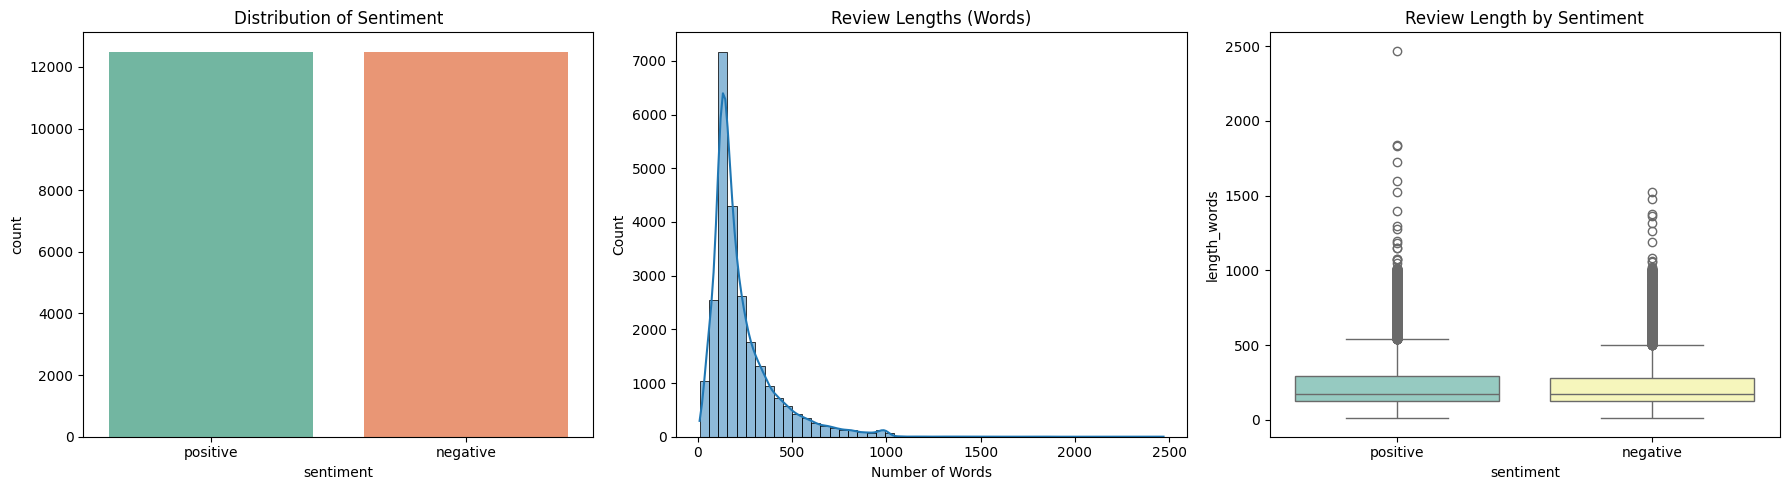

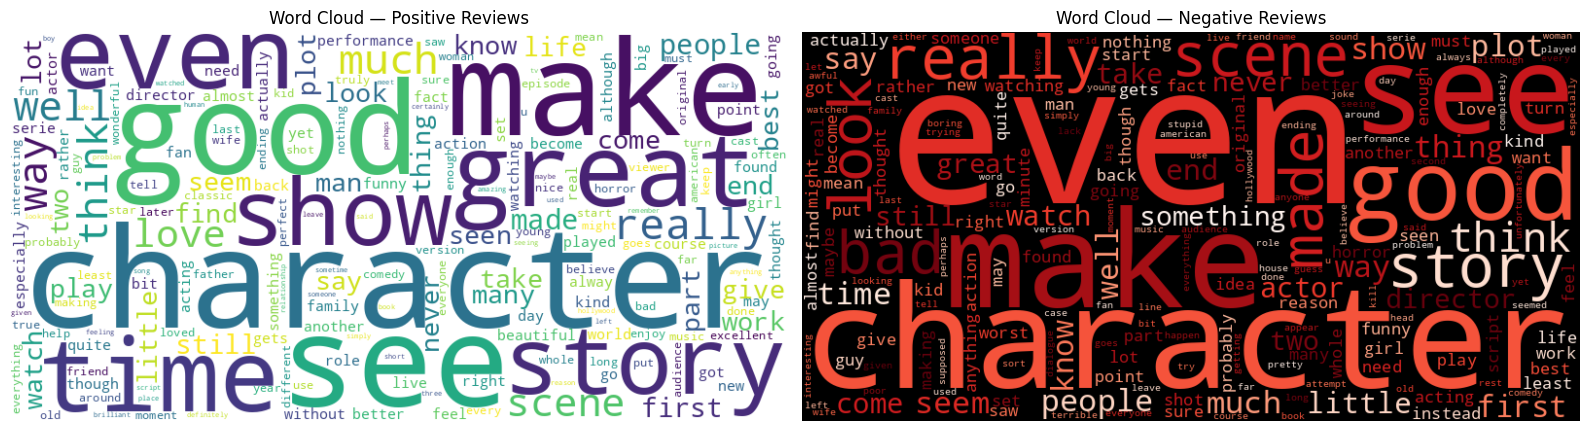

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
import os
from nltk.tokenize import TreebankWordTokenizer

# ─── 1. Prepare stop-words ─────────────────────────────────────────────────────
nltk.download('stopwords', quiet=True)
nltk_sw   = set(stopwords.words('english'))
wc_sw     = set(STOPWORDS)
custom_sw = {'movie', 'film', 'one', 'movies', 'films', 'br'}
all_stopwords = nltk_sw | wc_sw | custom_sw

# ─── 2. Load reviews into a DataFrame ──────────────────────────────────────────
# assume all_reviews = [(text, label), …] is already defined
df = pd.DataFrame(all_reviews, columns=["review", "sentiment"])
df["sentiment"] = df["sentiment"].map({1: "positive", 0: "negative"})

# compute length in words and characters
df["length_words"] = df["review"].str.split().str.len()
df["length_chars"] = df["review"].str.len()

# ─── 3. Plot 1–3 in a single figure ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sentiment distribution
sns.countplot(data=df, x="sentiment", palette="Set2", ax=axes[0])
axes[0].set_title("Distribution of Sentiment")

# 2. Distribution of review lengths (words)
sns.histplot(df["length_words"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Review Lengths (Words)")
axes[1].set_xlabel("Number of Words")

# 3. Boxplot of length by sentiment
sns.boxplot(data=df, x="sentiment", y="length_words", palette="Set3", ax=axes[2])
axes[2].set_title("Review Length by Sentiment")

fig.tight_layout()
fig.savefig("first_plots.png", dpi=300)   # save the 1×3 plots
plt.show()

# ─── 4. Preprocess text for word clouds ────────────────────────────────────────
tokenizer = TreebankWordTokenizer()

def preprocess_text(text):
    """Lowercase, tokenize, keep only alphabetic tokens not in our stop-words."""
    tokens = tokenizer.tokenize(text.lower())
    return " ".join(
        w for w in tokens
        if w.isalpha() and w not in all_stopwords
    )

df['clean_review'] = df['review'].apply(preprocess_text)

# ─── 5. Generate the two word clouds in one figure ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (sentiment, bg_color, cmap, title) in zip(
        axes,
        [
            ("positive", "white", None, "Word Cloud — Positive Reviews"),
            ("negative", "black", "Reds", "Word Cloud — Negative Reviews")
        ]
    ):
    # join all cleaned reviews for this sentiment
    text = " ".join(df[df["sentiment"] == sentiment]["clean_review"])
    wc = WordCloud(
        width=800, height=400,
        background_color=bg_color,
        colormap=cmap,
        stopwords=all_stopwords
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis("off")
    ax.set_title(title)

fig.tight_layout()
fig.savefig("wordclouds.png", dpi=300)    # save the 1×2 word-clouds
plt.show()


# NLP Analysis

This section performs sentiment classification on movie reviews using a fine-tuned DistilBERT model. It starts by loading and cleaning a labeled dataset of 50,000 reviews, then tokenizes the text using a pre-trained DistilBERT tokenizer. The data is converted into tensors and fed into a PyTorch DataLoader. The DistilBERT model is fine-tuned over several epochs using an AdamW optimizer and learning rate scheduler. Finally, the trained model is evaluated on the test set with performance metrics like the classification report and confusion matrix.

In [28]:
import os
import random
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from bs4 import BeautifulSoup
from sklearn.metrics import classification_report, confusion_matrix

# For compatibility with different versions of transformers
try:
    from transformers import get_linear_schedule_with_warmup
except ImportError:
    from transformers.optimization import get_linear_schedule_with_warmup

# -----------------------------
# 1. Preprocessing Utilities
# -----------------------------
def clean_html(text):
    """
    Remove HTML tags from text using BeautifulSoup.
    """
    return BeautifulSoup(text, "html.parser").get_text()

def load_reviews_from_dir(directory, label):
    """
    Load and clean reviews from directory, associating each with its label (0 or 1).
    """
    reviews = []
    for fn in os.listdir(directory):
        path = os.path.join(directory, fn)
        with open(path, "r", encoding="utf-8") as f:
            raw_text = f.read()
            cleaned_text = clean_html(raw_text)
            reviews.append((cleaned_text, label))
    return reviews

# -----------------------------
# 2. Load Full Dataset (50,000)
# -----------------------------
base = "extracted_dataset/aclImdb"
train_pos = load_reviews_from_dir(f"{base}/train/pos", 1)
train_neg = load_reviews_from_dir(f"{base}/train/neg", 0)
test_pos  = load_reviews_from_dir(f"{base}/test/pos", 1)
test_neg  = load_reviews_from_dir(f"{base}/test/neg", 0)

train_samples = train_pos + train_neg  # 25,000 reviews
test_samples  = test_pos + test_neg    # 25,000 reviews

random.seed(42)
random.shuffle(train_samples)
random.shuffle(test_samples)

train_texts, train_labels = zip(*train_samples)
test_texts,  test_labels  = zip(*test_samples)

# -----------------------------
# 3. Tokenization
# -----------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(texts, labels):
    """
    Tokenize and encode texts using DistilBERT tokenizer.
    """
    enc = tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )
    enc["labels"] = torch.tensor(labels)
    return enc

train_enc = tokenize(train_texts, train_labels)
test_enc  = tokenize(test_texts,  test_labels)

# -----------------------------
# 4. Create TensorDatasets and DataLoaders
# -----------------------------
train_ds = TensorDataset(
    train_enc["input_ids"], train_enc["attention_mask"], train_enc["labels"]
)
test_ds = TensorDataset(
    test_enc["input_ids"], test_enc["attention_mask"], test_enc["labels"]
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

# -----------------------------
# 5. Model, Optimizer, Scheduler
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 3
total_steps = len(train_loader) * num_epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# -----------------------------
# 6. Training Loop
# -----------------------------
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for input_ids, attention_mask, labels in train_loader:
        input_ids, attention_mask, labels = [
            t.to(device) for t in (input_ids, attention_mask, labels)
        ]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch}/{num_epochs} — Train Loss: {avg_loss:.4f}")

# -----------------------------
# 7. Evaluation
# -----------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = torch.argmax(logits, dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

# -----------------------------
# 8. Metrics
# -----------------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["neg", "pos"], digits=4))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 — Train Loss: 0.2912
Epoch 2/3 — Train Loss: 0.1395
Epoch 3/3 — Train Loss: 0.0651

Classification Report:
              precision    recall  f1-score   support

         neg     0.9361    0.9271    0.9316     12500
         pos     0.9278    0.9367    0.9322     12500

    accuracy                         0.9319     25000
   macro avg     0.9320    0.9319    0.9319     25000
weighted avg     0.9320    0.9319    0.9319     25000

Confusion Matrix:
[[11589   911]
 [  791 11709]]


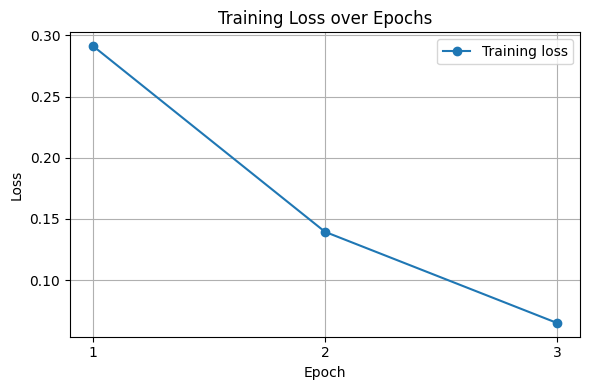

In [13]:
import matplotlib.pyplot as plt

# Observed loss from the previous results
train_losses = [0.2912, 0.1395, 0.0651]
epochs = [1, 2, 3]

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, marker='o', label="Training loss")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()